Petran van Rens

BERN02 - Assignment 2


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import math

table = pd.read_csv("bird_count.csv")

In [39]:
count = table['count']
# rescale year numbers
year = table['yr'] - 1998

table = pd.DataFrame({'year': year, 'count': count})
table = table.sort_values(by='year').reset_index(drop=True)

year_arr = table['year'].values
count_arr = table['count'].values

In [40]:

# ---------------------------------------------------------------
# 2. Negative log-likelihood for Poisson regression
#    Model: count_i ~ Poisson(lambda_i),  lambda_i = exp(b0 + b1 * year_i)
# ---------------------------------------------------------------
def log_likelihood(params, year, count):
    b0, b1 = params
    lam = np.exp(b0 + b1 * year)
    log_factorial = np.array([math.log(math.factorial(int(y))) for y in count])
    log_lik = np.sum(-lam + count * (b0 + b1 * year) - log_factorial)
    return log_lik  # the actual log-likelihood (not negated)

In [41]:
initial_guess = [0.0, 0.0]
result = minimize(
    lambda params, year, count: -1*log_likelihood(params, year, count),
    x0=initial_guess,
    args=(year_arr, count_arr),
)
 
beta_0, beta_1 = result.x
print(f"beta_0 = {beta_0:.4f}")
print(f"beta_1 = {beta_1:.4f}")

beta_0 = 2.3578
beta_1 = -0.0324


In [42]:
# Fitted mean (lambda) for each observed year, using the point estimates
lam_hat = np.exp(beta_0 + beta_1 * year_arr)


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_6104\500685246.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


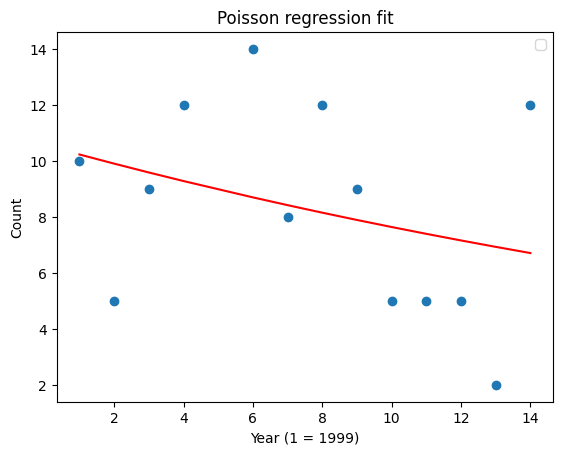

In [ ]:
plt.scatter(table['year'], table['count'])
plt.plot(table['year'], lam_hat, color='red')
plt.xlabel('Year (1 = 1999)')
plt.ylabel('Count')
plt.title('Poisson regression fit')
plt.savefig("poisson_fit.png", dpi=150, bbox_inches="tight")
plt.show()


In [44]:
samples = []
for s in range(1, 4):
    sim_counts = np.random.poisson(lam_hat)
    samples.append(pd.DataFrame({
        'year': table['year'] + 1998,  
        'count': sim_counts,
        'sample': s
    }))

samples_df = pd.concat(samples, ignore_index=True)
samples_df.to_csv("simulated_samples.csv", index=False)
print(samples_df)

    year  count  sample
0   1999     10       1
1   2000      9       1
2   2001      6       1
3   2002     10       1
4   2004     11       1
5   2005      4       1
6   2006      8       1
7   2007      8       1
8   2008      8       1
9   2009      8       1
10  2010      7       1
11  2011      4       1
12  2012     10       1
13  1999      8       2
14  2000     17       2
15  2001      4       2
16  2002     14       2
17  2004     10       2
18  2005      6       2
19  2006     11       2
20  2007      9       2
21  2008      7       2
22  2009     10       2
23  2010      6       2
24  2011      2       2
25  2012      9       2
26  1999      7       3
27  2000      7       3
28  2001      4       3
29  2002      9       3
30  2004     12       3
31  2005      9       3
32  2006      6       3
33  2007     10       3
34  2008     10       3
35  2009      5       3
36  2010      6       3
37  2011     14       3
38  2012      6       3
